In [169]:
import pandas as pd
import numpy as np

df = pd.read_stata("country.dta")

vars_keep = [
"id","code","country",
"trust","articles","democ","xconst",
"area","abslat","temp","climate","malfal",
"hmicost_hgdp",
"continent","africa","europe","asia","oceania","americas",
"cleangdp","cleantrust",
"gdppc2000","ln_gdppc2000","school"
]

df_new = df[vars_keep]

df_new["ln_gdppc2000"] = np.log(df_new["gdppc2000"])

In [170]:
life = pd.read_csv("lifeexpectancy.csv")
life2000 = life[life["Year"] == 2000]
life2000 = life2000[["Code", "Life expectancy"]]

life2000 = life2000.rename(columns={
    "Code": "code",
    "Life expectancy": "life_expectancy"
})

life2000

,code,life_expectancy
50,AFG,55.0047
126,NaN,53.6670
200,ALB,74.8262
277,DZA,70.5759
351,ASM,71.4429
...,...,...
21238,ESH,62.7345
21319,OWID_WRL,66.4333
21393,YEM,62.7610
21467,ZMB,46.5771


In [171]:
hc = pd.read_csv("human-capital-index-in-2018.csv")
hc2010 = hc[hc["Year"] == 2010]
hc2010 = hc2010[["Code", hc.columns[3]]]

hc2010 = hc2010.rename(columns={
    "Code": "code",
    "Human Capital Index (HCI) (scale 0-1)": "human_capital_index"
})

hc2010


,code,human_capital_index
3,ALB,0.543603
7,DZA,0.531283
16,ARG,0.588557
23,AUS,0.754844
27,AUT,0.737782
...,...,...
571,GBR,0.765454
575,USA,0.691508
579,URY,0.590905
587,VNM,0.656642


In [172]:
median = pd.read_csv("median-age.csv")
median2000 = median[median["Year"] == 2000]
median2000 = median2000[["Code", "Median age, total"]]

median2000 = median2000.rename(columns={
    "Code": "code",
    "Median age, total": "median_age"
})

median2000

,code,median_age
50,AFG,13.989
201,NaN,17.129
352,ALB,26.217
503,DZA,20.767
654,ASM,20.341
...,...,...
37498,ESH,21.766
37649,OWID_WRL,25.131
37800,YEM,14.368
37951,ZMB,14.798


In [173]:
olddep = pd.read_csv("age-dependency-ratio-old.csv")
olddep2000 = olddep[olddep["Year"] == 2000]
olddep2000 = olddep2000[["Code", "Age dependency ratio, old (% of working-age population)"]]
olddep2000 = olddep2000.rename(columns={
    "Code": "code",
    "Age dependency ratio, old (% of working-age population)": "old_dependency_ratio"
})

olddep2000

,code,old_dependency_ratio
50,AFG,4.740784
124,OWID_AFR,5.990227
198,UN_AFR,5.990179
272,ALB,11.617421
346,DZA,7.079100
...,...,...
19068,ESH,4.344248
19142,OWID_WRL,10.881923
19216,YEM,5.707387
19290,ZMB,4.760423


In [174]:
life2000.columns

Index(['code', 'life_expectancy'], dtype='str')

In [175]:
df_final = df_new \
    .merge(life2000, on="code", how="left") \
    .merge(hc2010, on="code", how="left") \
    .merge(median2000, on="code", how="left") \
    .merge(olddep2000, on="code", how="left")

In [176]:
df_clean = df_final[df_final.isna().sum(axis=1) <= 2]

df_clean

,id,code,country,trust,articles,democ,xconst,area,abslat,temp,...,americas,cleangdp,cleantrust,gdppc2000,ln_gdppc2000,school,life_expectancy,human_capital_index,median_age,old_dependency_ratio
7,8.0,ARG,Argentina,0.196044,0.053352,4.146340,3.70732,2736690.0,34.000000,13.966665,...,1,1,1,11331.958041,9.335382,6.630000,73.9100,0.588557,26.837,15.532346
11,12.0,AUS,Australia,0.446177,0.666427,10.000000,7.00000,7682300.0,27.000000,21.334566,...,0,1,1,25834.539707,10.159468,9.967778,79.6207,0.754844,34.369,18.429470
12,13.0,AUT,Austria,0.326583,0.391366,10.000000,7.00000,82450.0,47.333332,6.847278,...,0,1,1,26999.766761,10.203584,7.732222,78.2350,0.737782,37.140,22.860240
14,15.0,BDI,Burundi,NaN,0.001057,0.235294,1.47059,25680.0,3.500000,20.730478,...,0,1,0,698.843742,6.549427,1.230000,47.6166,0.342875,14.635,4.863706
15,16.0,BEL,Belgium,0.312535,0.450251,10.000000,7.00000,30230.0,50.833332,9.525276,...,0,1,1,24661.913793,10.113015,8.125555,77.7684,0.752727,37.893,25.608976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,194.0,USA,United States,0.412229,0.712341,10.000000,7.00000,9161920.0,38.000000,6.528523,...,1,1,1,34364.500621,10.444779,10.862220,76.8058,0.691508,34.291,18.259708
198,199.0,VNM,Vietnam,0.478134,0.001155,0.000000,3.00000,311060.0,16.000000,24.379883,...,0,0,1,2189.407890,7.691386,3.810000,72.7455,0.656642,22.686,9.569427
204,205.0,ZAF,South Africa,0.197655,0.064626,7.358970,7.00000,1214470.0,29.000000,17.958191,...,0,1,1,8226.062521,9.015063,5.315556,58.3678,0.425338,20.805,7.863221
206,207.0,ZMB,Zambia,0.115467,0.003883,1.972970,2.40541,743390.0,15.000000,21.567135,...,0,1,1,865.649397,6.763480,3.276667,46.5771,NaN,14.798,4.760423


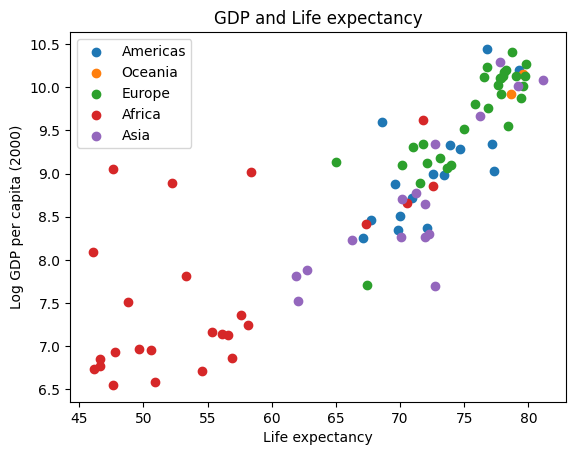

In [177]:
import matplotlib.pyplot as plt

plt.figure()

for c in df_clean["continent"].unique():
    subset = df_clean[df_clean["continent"] == c]
    plt.scatter(subset["life_expectancy"], subset["ln_gdppc2000"], label=c)

plt.xlabel("Life expectancy")
plt.ylabel("Log GDP per capita (2000)")
plt.title("GDP and Life expectancy")
plt.legend()

plt.show()

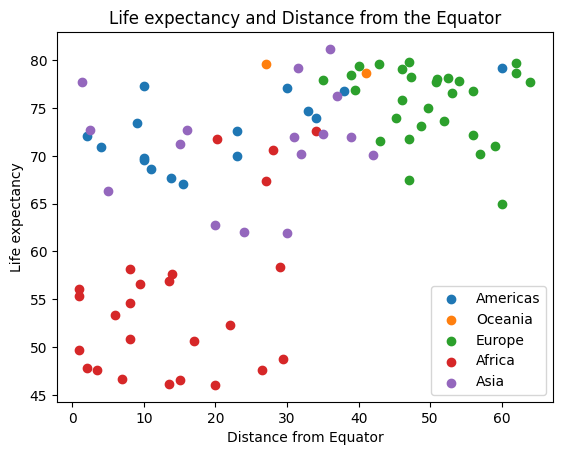

In [178]:
import matplotlib.pyplot as plt

plt.figure()

for c in df_clean["continent"].unique():
    subset = df_clean[df_clean["continent"] == c]
    plt.scatter(subset["abslat"], subset["life_expectancy"], label=c)

plt.xlabel("Distance from Equator")
plt.ylabel("Life expectancy")
plt.title("Life expectancy and Distance from the Equator")
plt.legend()

plt.show()

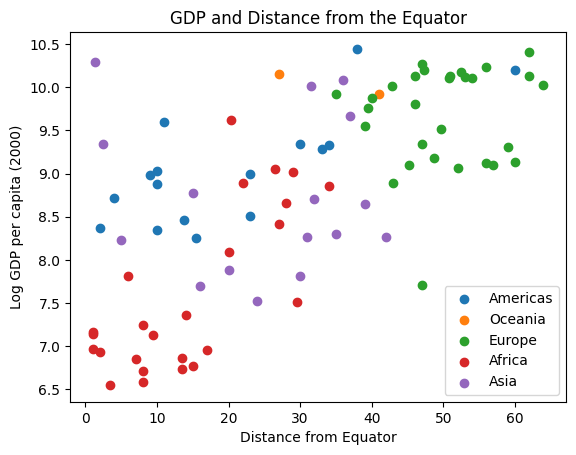

In [179]:
import matplotlib.pyplot as plt

plt.figure()

for c in df_clean["continent"].unique():
    subset = df_clean[df_clean["continent"] == c]
    plt.scatter(subset["abslat"], subset["ln_gdppc2000"], label=c)

plt.xlabel("Distance from Equator")
plt.ylabel("Log GDP per capita (2000)")
plt.title("GDP and Distance from the Equator")
plt.legend()

plt.show()